# Malware Detection Using Classifier Models vs Outlier Detection Techniques
By: Aya Abdelgawad

An extentsion of a previous group project in which the members were:
- Aya Abdelgawad
- Eric Ge 
- Jay Acosta
- Vandana George

## The Goal: Compare Oulier Detection vs Classification Models
Security researchers and developers of antivirus software both seek to apply ML models to make malware detection more sophisticated and able to keep up with the ever-evolving threat of malware. A common technique is to apply classifiers to this problem, and extensions of this work seek to develop models with finer-grained classification capabilities, able to explain which family of malware this threat belongs to. However, one limitation with this approach is that accuracy tends to suffer when executables from novel malware families are presented to these models (a likely occurance, since new styles and techniques for malware are constantly being developed). One potential approach is to use outlier detector models instead of classifiers. While this approach may not provide as much detailed information as a multi-family classification system, it may withstand the test of time better as new malware is developed as we speak.


In a previous version of this project, we investigated how different classification models performed for detecting the presence of malicious code in an executable. The results of the previous project showed that the best classifiers are random forests, decision trees, and SVMs (in that order). However, when analyzing the raw data, we noticed that frequently, the legitimate executables would cluster around some typical values for a particular feature while malicious executables would have wildly different values. This inspired a further investigation, which we will now conduct, to analyze how outlier detection methods would perform for this problem, and if they would be better than classifiers. One anticipated benefit of 

### Comparison Criteria
We will compare classifiers to outlier detectors using 2 main dimensions:
1. **Correctness** - which model is more "correct" is measured not just by the accuracy it acheives but also with a custom cost function we define in which a FP (marking a file as malicious when it is actually harmless) has a harsher penalty than a FN so that users are not constantly bombarded with alerts that a file may be dangerous.
2. **Efficiency** - we measure a model's efficiency as the amount of time it takes to train _and_ predict on a given dataset. We cannot split this up and compare solely training time or solely predicting time because outlier detector models train and label data all in one go. 

### Dataset Overview
The dataset we will be using was supplied by Max Secure Partner for a malware detection competition. It includes metadata on thousands of Portable Executable (PE) files, a common executable format on Windows machines. The first half of the features collected come from the fields of the PE header (see [the documentation](https://docs.microsoft.com/en-us/windows/win32/debug/pe-format) for more details), and the latter half come from analysis that Max Secure Partner collected while the program was running. The final field labels the program as either legitimate or not (i.e., containing malicious code). Some examples of the metrics included are the length of the header, the flags for the file, its hash, and the min/max/average entropy of the resources it uses while running.

In [29]:
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt

from sklearn.ensemble import VotingClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, make_scorer
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

import time
import warnings

%matplotlib inline

### Data Cleaning
In this section, we read in and the data and make sure it's all properly formatted. This section is exactly the same as in the previous project, in order to stay consistent with how the classification models were trained.

In [2]:
# read in data using low_memory=False so it can properly read in the md5 hashes as strings
data = pd.read_csv('Kaggle-data.csv', low_memory=False)

# display description of all columns
pd.set_option('display.max_columns', None)
data.describe(include='all')

,ID,md5,Machine,SizeOfOptionalHeader,Characteristics,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,SectionAlignment,FileAlignment,MajorOperatingSystemVersion,MinorOperatingSystemVersion,MajorImageVersion,MinorImageVersion,MajorSubsystemVersion,MinorSubsystemVersion,SizeOfImage,SizeOfHeaders,CheckSum,Subsystem,DllCharacteristics,SizeOfStackReserve,SizeOfStackCommit,SizeOfHeapReserve,SizeOfHeapCommit,LoaderFlags,NumberOfRvaAndSizes,SectionsNb,SectionsMeanEntropy,SectionsMinEntropy,SectionsMaxEntropy,SectionsMeanRawsize,SectionsMinRawsize,SectionMaxRawsize,SectionsMeanVirtualsize,SectionsMinVirtualsize,SectionMaxVirtualsize,ImportsNbDLL,ImportsNb,ImportsNbOrdinal,ExportNb,ResourcesNb,ResourcesMeanEntropy,ResourcesMinEntropy,ResourcesMaxEntropy,ResourcesMeanSize,ResourcesMinSize,ResourcesMaxSize,LoadConfigurationSize,VersionInformationSize,legitimate,Unnamed: 57
count,216352.000000,216352,216352,216352.000000,216352.000000,216351.000000,216352.000000,2.163520e+05,2.163520e+05,2.163520e+05,2.163520e+05,2.163520e+05,2.163520e+05,2.163520e+05,2.163520e+05,216352.000000,216352.000000,216352.000000,216352.000000,216352.000000,216352.000000,216352.000000,2.163520e+05,2.163520e+05,2.163520e+05,216352.000000,216352.000000,2.163520e+05,2.163520e+05,2.163520e+05,2.163520e+05,2.163520e+05,2.163520e+05,216352.000000,216352.000000,216352.000000,216352.000000,2.163520e+05,2.163520e+05,2.163520e+05,2.163520e+05,2.163520e+05,2.163520e+05,216352.000000,216352.000000,216352.000000,216352.000000,216352.000000,216352.000000,216352.000000,216352.000000,2.163520e+05,2.163520e+05,2.163520e+05,2.163520e+05,216352.000000,216352.000000,1.0
unique,NaN,209329,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,9873531e6ba01adecf7e1e0f68c2df1a,332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,25,197618,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,108176.500000,NaN,NaN,225.390197,4658.018849,9.052688,4.297964,3.953857e+05,5.827978e+05,1.332425e+06,2.812198e+05,9.263616e+04,2.597506e+05,6.825622e+14,8.973149e+03,876.249815,5.891214,1.908686,65.019649,62.194170,4.915735,1.062089,8.306375e+05,1.444321e+03,1.198387e+08,2.211697,19125.945395,8.226597e+07,8.135296e+07,1.375880e+06,4.596753e+04,9.237207e+04,6.160888e+04,4.907304,4.500140,2.046629,6.780452,1.623791e+05,1.908853e+04,5.588631e+05,1.824943e+05,2.066624e+04,6.279258e+05,7.375374,114.004788,4.702134,24.093205,21.311201,3.758643,2.391066,5.149387,9.997022e+04,7.139624e+04,2.524535e+05,1.023401e+06,7.888492,0.348982,0.0
std,62455.587057,NaN,NaN,4.559983,7843.855241,71.522478,11.965284,1.962775e+07,2.841106e+07,7.337809e+07,1.254327e+07,9.922827e+06,6.712844e+06,1.121701e+17,7.194441e+05,1362.854293,183.580174,227.045651,1163.764427,1153.224766,1.041145,144.727471,6.859762e+06,5.878291e+03,4.965103e+08,0.500514,16258.493510,3.782155e+10,3.782156e+10,1.478766e+08,7.974684e+06,1.370714e+07,1.242031e+07,2.554187,1.121715,1.825340,1.049097,6.451482e+06,3.186122e+05,2.573865e+07,3.393885e+06,3.189600e+05,1.073093e+07,727.966935,137.024438,36.612958,267.169003,130.677090,1.305126,1.042133,1.864471,1.718201e+07,1.681531e+07,2.433613e+07,4.772522e+07,8.049384,0.476649,NaN
min,1.000000,NaN,NaN,176.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.553600e+04,0.000000e+00,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0

Looking at the description of our dataframe, we immediately see two columns that have nothing to do with the data and can be dropped: 'ID' (which is jus the row id) and 'Unnamed: 57' (which was likely created due to an error while reading in the csv data). Let's go ahead and get rid of those features.

In [3]:
data = data.drop(columns=['ID', 'Unnamed: 57'])

Next, let's check the dataframe for NaNs. Notice from the output below there is only 1 record that contains any NaNs (and only for 1 feature). Since we have hundreds of thousands of records, it will not hurt us to just remove that 1 record.

In [4]:
# print out any features that have non-0 NaNs
col_nans = data.isna().sum()
for i in range(len(col_nans)):
    if col_nans.iloc[i] > 0:
        print(f"{data.columns[i]} has {col_nans.iloc[i]} NaNs")

# drop the row with the NaN
print("# of rows before dropping: " + str(data.shape[0]))
data = data.dropna()
print("# of rows after dropping: " + str(data.shape[0]))

MajorLinkerVersion has 1 NaNs
# of rows before dropping: 216352
# of rows after dropping: 216351


Many of our attributes are represented numerically, but some of them really make more sense as categorical variables. The featuers 'Characteristics', 'DllCharacteristics', and 'LoaderFlags' are actually each a set of about 16 binary flags (and would map to 16 features each). We will handle that mapping problem later on in the feature engineering section by implementing a custom one-hot-encoding method. Here, we will properly format the 'Machine' and 'Subsystem' features, which are codes that map to a particular CPU and subsystem needed to support the PE, respectively.

We'll start by cleaning the 'Machine' feature. Since there are many possible machine codes and only 8 present in our dataset, let's first review the values we have so we only need to map those values.

In [5]:
# print all unique values for machine code
print(data['Machine'].unique())

# there's one strange machine code value...is it legitimate?
strange_machine_code = data[data['Machine'] == '3ab1aa9785d0681434766bb0ffc4a13c']['legitimate']
print(strange_machine_code)

['332' '34404' '450' '422' '512' '43620'
 '3ab1aa9785d0681434766bb0ffc4a13c' '452']
41963    0
Name: legitimate, dtype: int64


The above output contains all valid possible values except for the strange hex one. As suspected, it belongs to an illegitimate executable. We will keep this in mind when mapping the values and be sure to label unexpected/invalid values as errors.

In [6]:
# Mapping values in Machine to their meaning - Machine will now be categorical
machine_keys = {
  "332": "IMAGE_FILE_MACHINE_I386",
  "422": "IMAGE_FILE_MACHINE_SH4",
  "450": "IMAGE_FILE_MACHINE_THUMB",
  "452": "IMAGE_FILE_MACHINE_ARMNT",
  "512": "IMAGE_FILE_MACHINE_IA64",
  "34404": "IMAGE_FILE_MACHINE_AMD64",
  "43620": "IMAGE_FILE_MACHINE_ARM64"
}
data['Machine'] = data['Machine'].map(machine_keys).fillna("IMAGE_FILE_MACHINE_ERROR")
print("Unique values for Machine feature are now:")
print(data['Machine'].unique())

# Mapping values in Subsystem to their meaning - Subsystem will now be categorical
subsystem_keys = {
  0: "IMAGE_SUBSYSTEM_UNKNOWN",
  1: "IMAGE_SUBSYSTEM_NATIVE",
  2: "IMAGE_SUBSYSTEM_WINDOWS_GUI",
  3: "IMAGE_SUBSYSTEM_WINDOWS_CUI",
  5: "IMAGE_SUBSYSTEM_OS2_CUI",
  7: "IMAGE_SUBSYSTEM_POSIX_CUI",
  9: "IMAGE_SUBSYSTEM_WINDOWS_CE_GUI",
  10: "IMAGE_SUBSYSTEM_EFI_APPLICATION",
  11: "IMAGE_SUBSYSTEM_EFI_BOOT_SERVICE_DRIVER",
  12: "IMAGE_SUBSYSTEM_EFI_RUNTIME_DRIVER",
  13: "IMAGE_SUBSYSTEM_EFI_ROM",
  14: "IMAGE_SUBSYSTEM_XBOX",
  16: "IMAGE_SUBSYSTEM_WINDOWS_BOOT_APPLICATION"
}
data['Subsystem'] = data['Subsystem'].map(subsystem_keys).fillna("IMAGE_SUBSYSTEM_ERROR")
print("Unique values for Subsystem feature are now:")
print(data['Subsystem'].unique())

Unique values for Machine feature are now:
['IMAGE_FILE_MACHINE_I386' 'IMAGE_FILE_MACHINE_AMD64'
 'IMAGE_FILE_MACHINE_THUMB' 'IMAGE_FILE_MACHINE_SH4'
 'IMAGE_FILE_MACHINE_IA64' 'IMAGE_FILE_MACHINE_ARM64'
 'IMAGE_FILE_MACHINE_ERROR' 'IMAGE_FILE_MACHINE_ARMNT']
Unique values for Subsystem feature are now:
['IMAGE_SUBSYSTEM_WINDOWS_GUI' 'IMAGE_SUBSYSTEM_WINDOWS_CE_GUI'
 'IMAGE_SUBSYSTEM_WINDOWS_CUI' 'IMAGE_SUBSYSTEM_NATIVE'
 'IMAGE_SUBSYSTEM_WINDOWS_BOOT_APPLICATION' 'IMAGE_SUBSYSTEM_UNKNOWN']


### Data Exploration
Time to create some visualizations to get a better understanding of our data!

Let's start by getting an overview of how our variables are correlated. This will give us an idea of which variables are giving us similar information. Below, we see a correlation matrix of all our variables, with darker backgrounds representing higher correlations. 

In [7]:
# display color-coordinated correlation matrix
correlatable = data.select_dtypes(include='number')

correlatable.corr().style.background_gradient()

,SizeOfOptionalHeader,Characteristics,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,SectionAlignment,FileAlignment,MajorOperatingSystemVersion,MinorOperatingSystemVersion,MajorImageVersion,MinorImageVersion,MajorSubsystemVersion,MinorSubsystemVersion,SizeOfImage,SizeOfHeaders,CheckSum,DllCharacteristics,SizeOfStackReserve,SizeOfStackCommit,SizeOfHeapReserve,SizeOfHeapCommit,LoaderFlags,NumberOfRvaAndSizes,SectionsNb,SectionsMeanEntropy,SectionsMinEntropy,SectionsMaxEntropy,SectionsMeanRawsize,SectionsMinRawsize,SectionMaxRawsize,SectionsMeanVirtualsize,SectionsMinVirtualsize,SectionMaxVirtualsize,ImportsNbDLL,ImportsNb,ImportsNbOrdinal,ExportNb,ResourcesNb,ResourcesMeanEntropy,ResourcesMinEntropy,ResourcesMaxEntropy,ResourcesMeanSize,ResourcesMinSize,ResourcesMaxSize,LoadConfigurationSize,VersionInformationSize,legitimate
SizeOfOptionalHeader,1.000000,0.071615,0.053298,-0.076454,0.070781,0.049606,-0.005530,0.004054,-0.002660,-0.011760,0.019496,-0.000996,-0.071197,0.000378,-0.001037,0.047413,0.045562,0.251709,0.000389,0.004230,-0.003871,-0.073063,-0.183426,0.006884,0.006888,0.006748,-0.001592,-0.002054,-0.001512,0.035673,-0.117299,-0.020237,-0.237927,0.001834,0.037031,0.001257,0.002144,0.035523,0.001468,0.050790,0.089659,0.061549,0.043154,0.042438,-0.012347,0.098977,-0.079851,-0.001586,-0.001286,-0.002461,-0.006537,0.226898,0.384716
Characteristics,0.071615,1.000000,-0.018760,0.350582,0.006158,0.000895,-0.006256,0.012908,0.024252,0.040869,-0.003584,-0.002533,-0.031585,0.000219,0.003649,0.018844,0.020239,-0.016919,0.000367,0.004624,0.004464,0.069708,-0.448730,-0.001269,-0.001263,-0.000489,0.013563,0.018273,0.001105,0.110902,-0.404926,-0.274831,-0.217150,0.006719,0.016332,0.007749,0.005352,0.017705,0.001200,0.000340,0.028534,-0.002077,0.030855,0.087461,-0.045767,-0.013748,-0.077281,-0.002910,-0.002365,-0.003526,-0.005389,0.020373,0.227615
MajorLinkerVersion,0.053298,-0.018760,1.000000,-0.018499,0.003884,0.002607,0.000574,-0.000356,0.002233,-0.000905,0.000166,0.012665,-0.001507,0.009608,0.004600,0.001575,0.001578,0.014387,-0.000040,-0.000286,0.289633,-0.001763,0.015580,-0.000032,-0.000032,-0.000067,-0.000170,0.000772,-0.000235,0.001602,0.014408,0.011275,-0.014804,-0.000280,0.000592,-0.000313,-0.000139,0.000462,-0.000244,0.996602,-0.005466,0.020855,-0.000439,-0.002058,0.234257,0.018066,-0.004062,-0.000013,0.000007,-0.000062,0.001329,-0.004347,0.009264
MinorLinkerVersion,-0.076454,0.350582,-0.018499,1.000000,0.049021,0.021032,0.024871,0.008945,0.027716,0.007506,0.000355,-0.002380,-0.045773,0.032757,0.056264,0.000674,0.001899,-0.142270,0.003746,0.000884,-0.001141,0.017566,-0.146422,-0.000769,-0.000773,-0.000853,0.002604,0.020263,0.006169,0.179522,-0.243994,-0.268962,-0.025004,-0.003158,-0.015828,-0.001415,-0.000176,-0.013972,-0.000612,0.000874,0.011616,-0.030335,-0.012139,0.011389,-0.037926,-0.076229,-0.028160,-0.001468,-0.001460,-0.000527,-0.000989,-0.190958,-0.123139
SizeOfCode,0.070781,0.006158,0.003884,0.049021,1.000000,0.320853,0.134945,0.001284,0.218070,0.196505,0.000070,0.000008,0.011037,-0.000083,-0.000114,0.029767,0.044001,-0.002515,-0.000090,0.005357,0.002000,0.001406,-0.007083,-0.000010,0.000013,0.008537,0.099918,0.094460,0.000028,0.003439,0.000994,-0.000633,-0.000903,0.000786,-0.000637,0.000848,0.001999,-0.000431,0.002349,0.000049,0.010195,0.007294,0.006128,0.004996,-0.005364,-0.004693,-0.003430,0.000245,0.000268,0.000164,-0.000263,-0.006280,-0.002950
SizeOfInitializedData,0.049606,0.000895,0.002607,0.021032,0.320853,1.000000,0.097395,0.001307,0.171767,0.153370,0.000034,-0.000085,0.001639,-0.000120,-0.000117,0.024663,0.045910,-0.005799,-0.000073,0.092431,0.000068,-0.001047,-0.008680,-0.000026,0.000005,0.006261,0.124824,0.089695,0.000006,-0.001066,0.007074,0.005983,0.003550,0.002330,0.010334,0.002098,0.051361,0.010526,0.058406,-0.000040,0.003124,0.002964,0.001146,0.010827,-0.002641,-0.007036,0.001968,-0.000007,-0.000060,0.0

Here are some highlights we found from the expansive output:
- The feature with the highest correlation to legitimacy was 'MajorSubsystemVersion', indicating that this is likely an important feature to keep for our analysis. Intuitively, this makes sense because we expect that older systems are more vulnerable to malware. 
- For the statistics measured, they come in 3's: mean, min, and max. As a general trend, there tended to be a high correlation between mean & min and mean & max. Intuitively, this makes sense because we expect the mean to summarize our entire data. We can utilize this by only using the mean feature in our training and not have to keep min or max.
- In the optional header, all of the entries have a fixed size, except the last one: 'NumberOfRvaAndSizes'. It tells us how many directory entries are in the header. 'SizeOfOptionalHeader' gives the total size of the header. Intuitively, these two variables are telling us very similar things (how big is the whole thing vs. how big is it beyond some fixed size). However, the correlation between 'NumberOfRvaAndSizes' and 'SizeOfOptionalHeader' is -0.001512! This contradiction to our expectation warrants some investigation, which we shall conduct in the coming cells. First, let's visualize the variables.

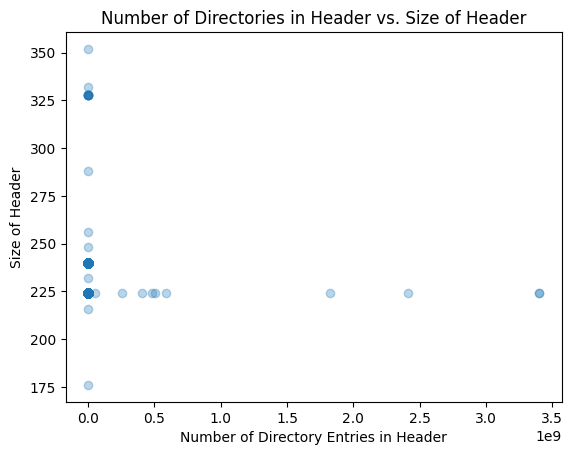

In [8]:
# Plot NumberOfRvaAndSizes vs. SizeOfOptionalHeader
plt.scatter(data['NumberOfRvaAndSizes'], data['SizeOfOptionalHeader'], alpha=0.3)
plt.xlabel('Number of Directory Entries in Header')
plt.ylabel('Size of Header')
plt.title('Number of Directories in Header vs. Size of Header')
plt.show()

We suspect that this odd behavior is caused by the malicious records. If we plot the same graph but only for legitimate and malicious records (as shown below), then we learn that all legitimate records have 16 directory entries and header sizes of 224-240 bytes (since directories are variable-sized, this variation is not surprising or alarming). The graph of malicious executables strongly resembles the one where we included all our dataset, indicating that the odd behavior originates from our malicious records. This trend is useful to keep in mind, as it indicates these features may be helpful for classification.

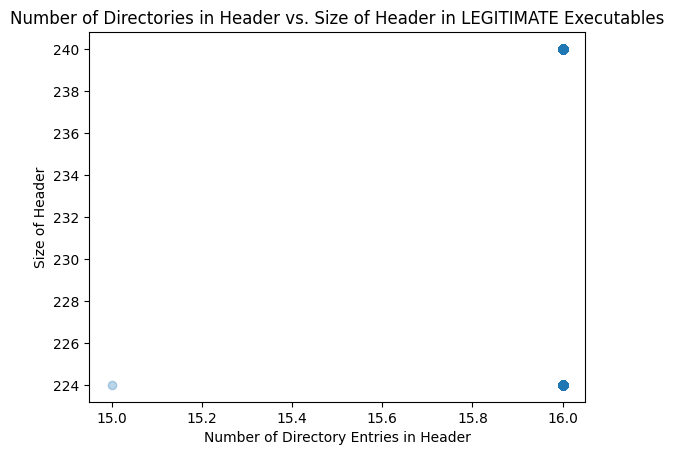

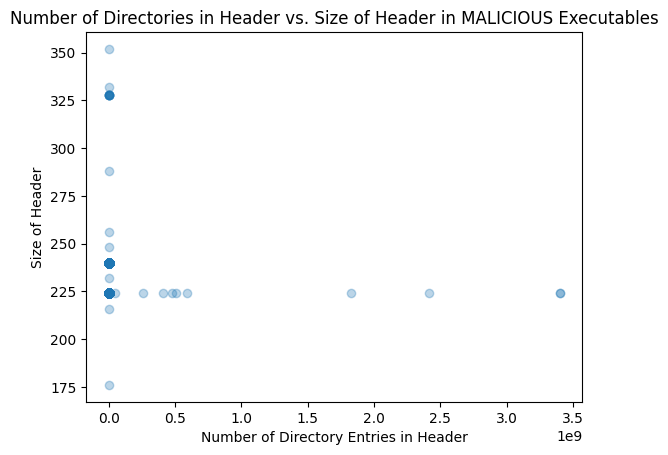

In [9]:
# plot for legitimate executables
legit = data[data['legitimate'] == 1]
plt.scatter(legit['NumberOfRvaAndSizes'], legit['SizeOfOptionalHeader'], alpha=0.3)
plt.xlabel('Number of Directory Entries in Header')
plt.ylabel('Size of Header')
plt.title('Number of Directories in Header vs. Size of Header in LEGITIMATE Executables')
plt.show()

# plot for malicious executables
not_legit = data[data['legitimate'] == 0]
plt.scatter(not_legit['NumberOfRvaAndSizes'], not_legit['SizeOfOptionalHeader'], alpha=0.3)
plt.xlabel('Number of Directory Entries in Header')
plt.ylabel('Size of Header')
plt.title('Number of Directories in Header vs. Size of Header in MALICIOUS Executables')
plt.show()

As mentioned earlier, we believe older systems should be more vulnerable to malware. This seems to be the case for MajorSubsystemVersion, based on the correlation noted earlier and by the boxplot below. 

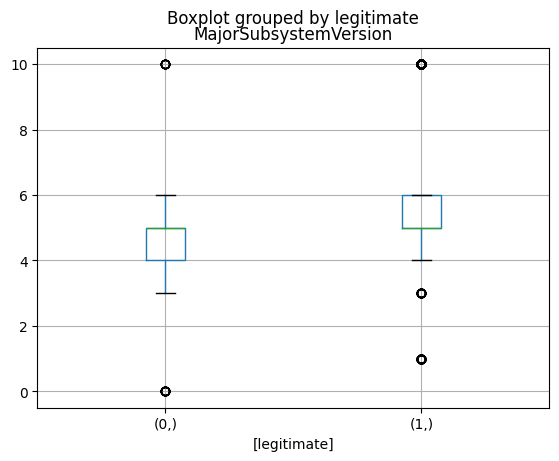

In [10]:
# sanity check: intuition says older subsys more vulnerable to malware
# let's see if this is true for our data
data.boxplot(column=['MajorSubsystemVersion'], by=['legitimate'])
plt.show()
# yeah most of data on lower end

We want to check if this trend also appears with the operating system version. However, when we make a boxplot, there are some strange outliers in the malicious records (unsurprisingly), so let's filter out the invalid values (the max valid value is 10). After filtering out invalid values, we see that malicious records do tend to belong to older systems.

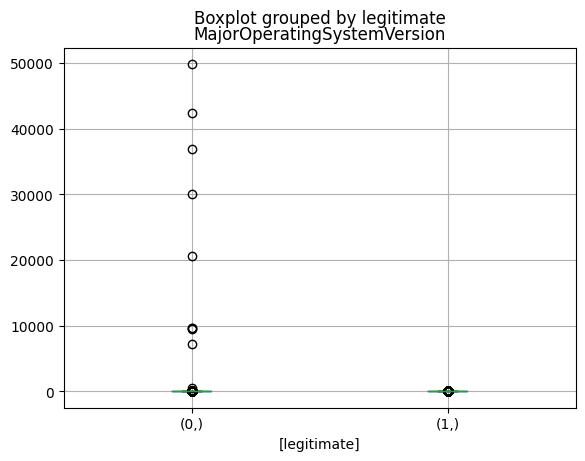

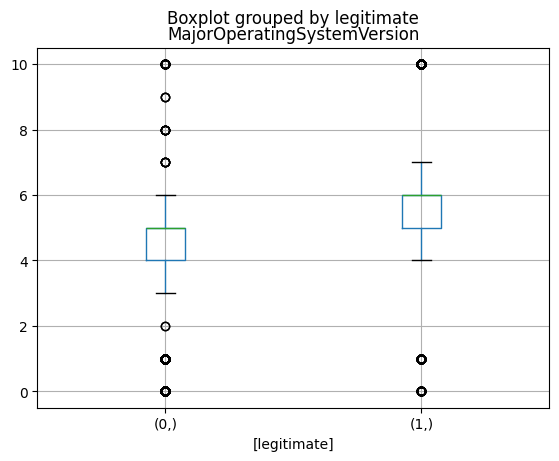

In [11]:

data.boxplot(column=['MajorOperatingSystemVersion'], by=['legitimate'])
# have some weird outliers in non-legit data, 
# so let's look at only valid values (10 or less)
noout = data[data['MajorOperatingSystemVersion'] < 11]
noout.boxplot(column=['MajorOperatingSystemVersion'], by=['legitimate'])
plt.show()
# yeah most of data on lower end

Let's also confirm that this trend applies with the linker version as well. Surprisingly, this doesn't seem to apply for the linker version, indicating we may not want to use it. Note we still see the greater variation among malicious record that we have come to expect.

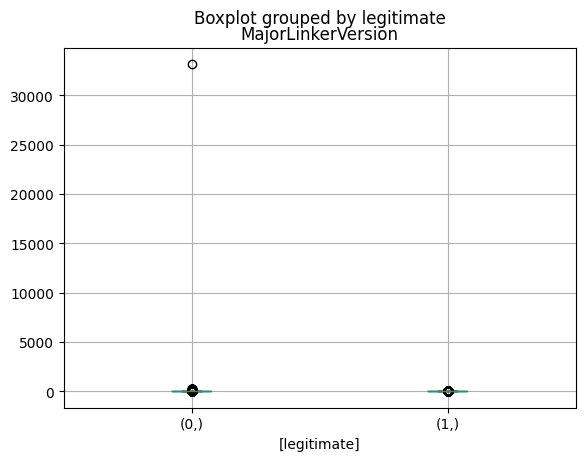

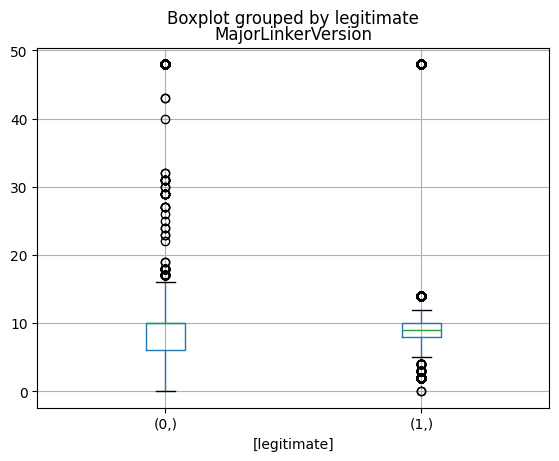

In [12]:
# sanity check: intuition says older linker more vulnerable to malware
# let's see if this is true for our data
data.boxplot(column=['MajorLinkerVersion'], by=['legitimate'])
# have some weird outliers in non-legit data -> remove
noout = data[data['MajorLinkerVersion'] < 50]
noout.boxplot(column=['MajorLinkerVersion'], by=['legitimate'])
plt.show()
# not strictly align with intuition, but noticing that there is a lot of variation in non-legit

### Feature Selection & Engineering
In this section, we will choose which features to drop based on their relevance to the problem of trying to detect malware. Some of these features will also need to be engineered, such as binning for the versioning features and implementing a custom one-hot-encoding method for the flag features.

Because 'MajorSubsytemVersion' follows a nice clean trend and doesn't have major outliers, we think two simple bins will work fine to describe the linker version: 5 or less is "old", greater than that is "new". However, we know that 'MajorOperatingSystemVersion' has some extremely strange values and large fluctionations, so that one we will bin 5 or less as "old", 6-10 as "new", and >10 as "invalid" because those do not currently correspond to real OS versions.

In [13]:
# bin subsys version
data['SubsystemVersion'] = pd.cut(
    data['MajorSubsystemVersion'], 
    [0, 5, max(data['MajorSubsystemVersion'])],
    labels=['old', 'new'],
    include_lowest=True)

# bin OS version
data['OSVersion'] = pd.cut(
    data['MajorOperatingSystemVersion'], 
    [0, 5, 10, max(data['MajorOperatingSystemVersion'])],
    labels=['old', 'new', 'invalid'],
    include_lowest=True)

# make sure no NaNs introduced
print ("Number of NaNs in SubsystemVersion:", data['SubsystemVersion'].isna().sum ())
print ("Number of NaNs in OSVersion:", data['OSVersion'].isna().sum ())

Number of NaNs in SubsystemVersion: 0
Number of NaNs in OSVersion: 0


Although 'Characteristics', 'DllCharacteristics', and 'LoaderFlags' are all flag features, we will only be implementing the custom one-hot-encoding for 'DllCharacteristics' because we do not want to keep all of the new features that would be created by feature engineering all three. This would increase the number of dimensions we have beyond a reasonable point. We choose to keep 'DllCharacterists' rather than any of the other flag features because we are interested in having context about the linker (because there are attacks that exploit linkers), and 'MajorLinkerVersion' did not seem as useful to us.

In [14]:
dll_flag_offsets = {
    5: "IMAGE_DLL_CHARACTERISTICS_HIGH_ENTROPY_VA", 
    6: "IMAGE_DLLCHARACTERISTICS_DYNAMIC_BASE",
    7: "IMAGE_DLLCHARACTERISTICS_FORCE_INTEGRITY",
    8: "IMAGE_DLLCHARACTERISTICS_NX_COMPAT",
    9: "IMAGE_DLLCHARACTERISTICS_NO_ISOLATION",
    10: "IMAGE_DLLCHARACTERISTICS_NO_SEH",
    11: "IMAGE_DLLCHARACTERISTICS_NO_BIND",
    12: "IMAGE_DLL_CHARACTERISTICS_APPCONTAINER",
    13: "IMAGE_DLLCHARACTERISTICS_WDM_DRIVER",
    14: "IMAGE_DLL_CHARACTERISTICS_GUARD_CF",
    15: "IMAGE_DLLCHARACTERISTICS_TERMINAL_SERVER_AWARE"}

for flag_offset in dll_flag_offsets:
    data[dll_flag_offsets[flag_offset]] = data['DllCharacteristics'].apply(lambda f: f >> flag_offset & 1)

We also need to do the normal one-hot-encode for our categorical varaibles: 'Machine' and 'Subsystem'.

In [15]:
encoded_data = pd.get_dummies(data, columns=['Subsystem', 'Machine'], drop_first=True)

Based on our analysis and understanding of the features, we think the features below will not be as helpful for determining if code is malicious (or, in the case of 'md5', it was just too much of a hassle to try to create such a large dataframe with every hash one-hot-encoded).

In [16]:
# will get rid of the following for preliminary cleaning:
clean_out = ['md5', 'Characteristics', 'MajorLinkerVersion', 'MinorLinkerVersion', 'SectionAlignment', 'FileAlignment', 'MajorOperatingSystemVersion', 'MinorOperatingSystemVersion', 'MajorImageVersion', 'MinorImageVersion', 'MajorSubsystemVersion', 'MinorSubsystemVersion', 'CheckSum', 'DllCharacteristics', 'SizeOfStackReserve', 'SizeOfStackCommit', 'SizeOfHeapReserve', 'SizeOfHeapCommit', 'LoaderFlags', 'SectionsMinEntropy', 'SectionsMaxEntropy', 'SectionsMinRawsize', 'SectionMaxRawsize', 'SectionsMinVirtualsize', 'SectionMaxVirtualsize', 'ResourcesMinEntropy', 'ResourcesMaxEntropy', 'ResourcesMinSize', 'ResourcesMaxSize']

# print out the number of features dropped
print("Features dropped:", len(clean_out))

data = encoded_data.drop(columns=clean_out)

# how many features do we have now?
print("Number of features in dataframe:", data.shape[1])

# check head to make sure features are as expect
data.head()


Features dropped: 29
Number of features in dataframe: 50


,SizeOfOptionalHeader,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,SizeOfImage,SizeOfHeaders,NumberOfRvaAndSizes,SectionsNb,SectionsMeanEntropy,SectionsMeanRawsize,SectionsMeanVirtualsize,ImportsNbDLL,ImportsNb,ImportsNbOrdinal,ExportNb,ResourcesNb,ResourcesMeanEntropy,ResourcesMeanSize,LoadConfigurationSize,VersionInformationSize,legitimate,SubsystemVersion,OSVersion,IMAGE_DLL_CHARACTERISTICS_HIGH_ENTROPY_VA,IMAGE_DLLCHARACTERISTICS_DYNAMIC_BASE,IMAGE_DLLCHARACTERISTICS_FORCE_INTEGRITY,IMAGE_DLLCHARACTERISTICS_NX_COMPAT,IMAGE_DLLCHARACTERISTICS_NO_ISOLATION,IMAGE_DLLCHARACTERISTICS_NO_SEH,IMAGE_DLLCHARACTERISTICS_NO_BIND,IMAGE_DLL_CHARACTERISTICS_APPCONTAINER,IMAGE_DLLCHARACTERISTICS_WDM_DRIVER,IMAGE_DLL_CHARACTERISTICS_GUARD_CF,IMAGE_DLLCHARACTERISTICS_TERMINAL_SERVER_AWARE,Subsystem_IMAGE_SUBSYSTEM_UNKNOWN,Subsystem_IMAGE_SUBSYSTEM_WINDOWS_BOOT_APPLICATION,Subsystem_IMAGE_SUBSYSTEM_WINDOWS_CE_GUI,Subsystem_IMAGE_SUBSYSTEM_WINDOWS_CUI,Subsystem_IMAGE_SUBSYSTEM_WINDOWS_GUI,Machine_IMAGE_FILE_MACHINE_ARM64,Machine_IMAGE_FILE_MACHINE_ARMNT,Machine_IMAGE_FILE_MACHINE_ERROR,Machine_IMAGE_FILE_MACHINE_I386,Machine_IMAGE_FILE_MACHINE_IA64,Machine_IMAGE_FILE_MACHINE_SH4,Machine_IMAGE_FILE_MACHINE_THUMB
0,224,16896,8192,0,16947,4096,24576,4194304.0,40960,1024,16,4,3.761598,6016.000000,6096.250000,3,44,0,31,1,3.492126,864.0,72,0,1,old,new,0,1,0,1,0,0,0,0,0,0,0,False,False,False,False,True,False,False,False,True,False,False,False
1,224,84480,25600,0,10973,4096,90112,65536.0,126976,1024,16,5,4.973822,22016.000000,21902.800000,2,102,100,2,1,3.486827,892.0,72,0,1,old,old,0,1,0,1,0,0,0,0,0,0,0,False,False,True,False,False,False,False,False,True,False,False,False
2,224,4608,3584,0,6452,4096,12288,264962048.0,24576,1024,16,4,3.329824,1792.000000,1708.000000,2,27,0,3,1,3.517270,952.0,72,0,1,new,new,0,1,0,1,0,0,0,0,0,0,0,False,False,False,False,True,False,False,False,True,False,False,False
3,224,108544,15872,0,105021,4096,114688,268435456.0,143360,1024,16,5,3.404831,24883.200000,25645.400000,12,66,0,105,2,3.270559,1032.0,72,0,1,new,new,0,1,0,1,0,0,0,0,0,0,0,False,False,False,True,False,False,False,False,True,False,False,False
4,224,513024,2048,0,520922,8192,524288,268435456.0,540672,512,16,3,2.978056,171690.666667,171265.333333,1,1,0,0,1,3.420977,954.0,0,0,1,new,old,1,1,0,1,0,1,0,0,0,0,1,False,False,False,True,False,False,False,False,True,False,False,False


### Trained Classifiers
We will now measure the accuracy and performance of the best-performing classifiers that we discovered through our previous project. The classifiers we tested were:
- Decision Trees
- K-Nearest Neighbors
- Neural Networks
- Random Forest
- SVM

However, before we jump into the classification portion, we need to address a few issues: class imbalance, and the scoring metric.

##### Mitigating Class Imbalance

Our dataset has a slight class imbalance. To mitigate this, we chose to undersample our dataset and run our models against this undersampled data.

In [47]:
num_legit = 75502
deep_copy_data = data.copy()
deep_copy_data = deep_copy_data.groupby("legitimate").sample(n=num_legit, random_state=2)
labels = random_tree_data["legitimate"]
features = random_tree_data.drop(columns = ["legitimate", 'OSVersion'])

num_legit = (random_tree_data['legitimate'] == 1).sum()
num_malicious = (random_tree_data['legitimate'] == 0).sum()

print ("Percent Malicious:", num_malicious / len (deep_copy_data))
print ("Percent Safe:", num_legit / len (deep_copy_data))
deep_copy_data.head ()

Percent Malicious: 0.5
Percent Safe: 0.5


,SizeOfOptionalHeader,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,SizeOfImage,SizeOfHeaders,NumberOfRvaAndSizes,SectionsNb,SectionsMeanEntropy,SectionsMeanRawsize,SectionsMeanVirtualsize,ImportsNbDLL,ImportsNb,ImportsNbOrdinal,ExportNb,ResourcesNb,ResourcesMeanEntropy,ResourcesMeanSize,LoadConfigurationSize,VersionInformationSize,legitimate,SubsystemVersion,OSVersion,IMAGE_DLL_CHARACTERISTICS_HIGH_ENTROPY_VA,IMAGE_DLLCHARACTERISTICS_DYNAMIC_BASE,IMAGE_DLLCHARACTERISTICS_FORCE_INTEGRITY,IMAGE_DLLCHARACTERISTICS_NX_COMPAT,IMAGE_DLLCHARACTERISTICS_NO_ISOLATION,IMAGE_DLLCHARACTERISTICS_NO_SEH,IMAGE_DLLCHARACTERISTICS_NO_BIND,IMAGE_DLL_CHARACTERISTICS_APPCONTAINER,IMAGE_DLLCHARACTERISTICS_WDM_DRIVER,IMAGE_DLL_CHARACTERISTICS_GUARD_CF,IMAGE_DLLCHARACTERISTICS_TERMINAL_SERVER_AWARE,Subsystem_IMAGE_SUBSYSTEM_UNKNOWN,Subsystem_IMAGE_SUBSYSTEM_WINDOWS_BOOT_APPLICATION,Subsystem_IMAGE_SUBSYSTEM_WINDOWS_CE_GUI,Subsystem_IMAGE_SUBSYSTEM_WINDOWS_CUI,Subsystem_IMAGE_SUBSYSTEM_WINDOWS_GUI,Machine_IMAGE_FILE_MACHINE_ARM64,Machine_IMAGE_FILE_MACHINE_ARMNT,Machine_IMAGE_FILE_MACHINE_ERROR,Machine_IMAGE_FILE_MACHINE_I386,Machine_IMAGE_FILE_MACHINE_IA64,Machine_IMAGE_FILE_MACHINE_SH4,Machine_IMAGE_FILE_MACHINE_THUMB
129622,224,118784,394752,0,59901,4096,122880,4194304.0,532480,1024,16,5,5.660150,102707.200000,1.041830e+05,7,112,0,0,24,6.912127,14429.000000,72,14,0,old,old,0,1,0,1,0,0,0,0,0,0,1,False,False,False,False,True,False,False,False,True,False,False,False
159796,224,105472,67584,0,67963,4096,110592,4194304.0,180224,1024,16,4,4.395204,40704.000000,4.296575e+04,4,106,2,0,6,3.632021,1082.333333,72,16,0,old,old,0,0,0,1,0,0,0,0,0,0,1,False,False,False,False,True,False,False,False,True,False,False,False
161588,224,113664,682496,0,24735,4096,118784,4194304.0,851968,1024,16,3,4.263377,94549.333333,2.814293e+05,4,7,1,0,7,4.453368,80992.857143,0,0,0,old,old,0,1,0,1,0,0,0,0,0,0,1,False,False,False,False,True,False,False,False,True,False,False,False
187224,224,28672,445952,16896,14819,4096,32768,4194304.0,8708096,1024,16,6,4.136090,10410.666667,1.449848e+06,8,172,1,0,9,4.243395,1895.666667,0,13,0,old,old,0,1,0,1,0,1,0,0,0,0,1,False,False,False,False,True,False,False,False,True,False,False,False
176476,224,36864,16896,0,38896,4096,40960,4194304.0,77824,1024,16,8,2.315874,6272.000000,6.768750e+03,8,95,0,0,14,3.978249,549.785714,0,13,0,old,old,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,True,False,False,False,True,False,False,False


##### Helper Methods

Next, we will define to some utility methods for evaluating our models. The `print_confusion_matrix` method will display a stylized table of a proximity matrix. `split_feats_labels` will split data into labels and features.  Lastly, the `get_scorer` method allows us to apply a cost matrix to a confusion matrix and get the cost of a model.


Additionally, we have also included the helper method `get_k_feat_names`, which returns the names of features from a `SelectKBest` object, which is sklearn's method of picking the best _K_ features to run on a dataset.

In [18]:
# from homework
def print_confusion_matrix(TN, FP, FN, TP):
    table_data = [[TP,FN],[FP,TN]]
    df = pd.DataFrame(table_data, columns =['Predicted Safe','Predicted Unsafe'])
    df = df.rename(index={0: 'Actual Safe', 1: 'Actual Unsafe'})
    display(df)

# written by Jay
def split_feats_labels (data, class_label='legitimate'):
    return data.drop (columns=[class_label]), data[class_label]

def get_k_feat_names (KBest, data):
    cols = KBest.get_support(indices=True)
    return [name for name in data.iloc[:,cols]]

"""
Cost Matrix: 
    pass in costs based on penalty for 
    these evaluations [TN, FP, FN, TP]

    when doing greater_is_better = False , sklearn chooses to have + as a penalty, and - as a reward
    reward correct classifications
    harsher penalty for marking malicious but actually safe
    lighter penalty for marking safe but actually malicious
"""
def get_scorer (cost_matrix=[-10, 100, 50, -10]):
    
    def calc_cost (y_true, y_pred, **kwargs):
        return (cost_matrix * confusion_matrix(y_true, y_pred).ravel()).sum ()
    
    return make_scorer (calc_cost, greater_is_better=False)

score = get_scorer ()

#### Decision Trees
When run over multiple iterations, we found the best parameters were a max depth of around 20, using 80% of the features during a split, and setting the minimum impurity decrease to about 0.0001. This tree is too large to clearly draw, but we can print out which are the most important features (the features that were split on very high up in the tree).

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV


# separate features and labels
features = deep_copy_data.groupby("legitimate").sample(n=num_legit, random_state=2)
labels = features.pop('legitimate')

# some housekeeping
# decision tree doensn't like working with pre-binned data,
# so we will let it bin the data for us during training
features_unbinned = features.drop(columns=['OSVersion', 'SubsystemVersion'])
features_unbinned['OSVersion'] = encoded_data['MajorOperatingSystemVersion']
features_unbinned['SubsystemVersion'] = encoded_data['MajorSubsystemVersion']



# make a decision tree and train on data
dec_tree = DecisionTreeClassifier(criterion='gini', max_depth=20, max_features=0.8, min_impurity_decrease=0.0001)
dec_tree.fit(features, labels)

# get evaluation metrics
dec_tree_avg_score = cross_val_score(dec_tree, features, labels, cv=10, scoring=score).mean()
pre_train_time = time.time() # timing how long it takes to predict w/ model
pred = cross_val_predict (dec_tree, features, labels, cv=5)
post_train_time = time.time()

print ("*** Average Score:", dec_tree_avg_score)
print()

print ("*** Average accuracy:", accuracy_score (labels, pred))
print_confusion_matrix (*confusion_matrix (labels, pred).ravel ())

print ("*** Classification Report:")
print (classification_report (labels, pred))

print("*** Efficiency:")
dec_tree_train_time = post_train_time - pre_train_time
print(f"Training time: {dec_tree_train_time:.8f} seconds")

print("\n*** Most Important Features:")
print("Feature:                                Importance:")
important_features = {}
for i in range(len(random_tree_data.columns) - 1):
    if(dec_tree.feature_importances_[i] > 0.009):
        # store the feature and its importance
        important_features[dec_tree.feature_importances_[i]] = random_tree_data.columns[i]

# print features in order of most important
for importance in sorted(important_features, reverse=True):
    print(f"{important_features[importance]:<40}{importance}")


*** Average Score: 113452.0

*** Average accuracy: 0.9710868586262615


,Predicted Safe,Predicted Unsafe
Actual Safe,73543,1959
Actual Unsafe,2407,73095


*** Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     75502
           1       0.97      0.97      0.97     75502

    accuracy                           0.97    151004
   macro avg       0.97      0.97      0.97    151004
weighted avg       0.97      0.97      0.97    151004

*** Efficiency:
Training time: 4.34074497 seconds

*** Most Important Features:
Feature:                                Importance:
ImageBase                               0.705292481289716
Subsystem_IMAGE_SUBSYSTEM_WINDOWS_GUI   0.1306458813299896
ResourcesMeanSize                       0.020711221538166603
OSVersion                               0.015364218846434538
ImportsNb                               0.014232087095436309
VersionInformationSize                  0.012445442211388272


From the output above, we can see that we can get fairly high accuracy, precision, and recall from our model (best of both worlds!). We also see that the key features our model is prioritizing when making a decision include the image base (the first byte of the image to start executing), the subsystem type, and the operating system version.

#### K-Nearest Neighbors
For K-Nearest Neighbors, we undersample even further and use 1,000 of each category to decrease runtime. For this model, the best parameters were to project down to a 15-dimentional PCA and to use the 2 closest neighbors.

In [42]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
le = LabelEncoder()

deep_copy_data = data.copy()
random_tree_data = deep_copy_data.groupby("legitimate").sample(n=num_legit, random_state=2)
pd.get_dummies(random_tree_data, columns=['SubsystemVersion'], drop_first=True)
labels = random_tree_data["legitimate"]
features = random_tree_data.drop(columns = ["legitimate", 'OSVersion'])
features["SubsystemVersion"]=le.fit_transform(features["SubsystemVersion"])

In [45]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

scalar = StandardScaler()
pca = PCA(n_components=15)
model = KNeighborsClassifier(n_neighbors=2)
pipeline = Pipeline(steps=[('scalar', scalar), ('pca', pca), ('model', model)])
pre_fit_time = time.time() # timing how long it takes to train model
pipeline.fit(features, labels)
post_fit_time = time.time()

knn_avg_score = cross_val_score(pipeline, features, labels, cv=10, scoring=score).mean()

pre_pred_time = time.time() # timing how long it takes to predict w/ model
pred = cross_val_predict(pipeline, features, labels, cv=5)
post_pred_time = time.time()

print("*** Average Score:", knn_avg_score)
print()

print("*** Average accuracy:", accuracy_score(labels, pred))
print_confusion_matrix(*confusion_matrix(labels, pred).ravel())

print("*** Efficiency:")
knn_train_time = post_fit_time - pre_fit_time
print(f"Training time: {knn_train_time:.8f} seconds")
knn_pred_time = post_pred_time - pre_pred_time
print(f"Prediction time: {knn_pred_time:.8f} seconds")
print()

print("*** Classification Report:")
print(classification_report(labels, pred))

*** Average Score: 117000.0

*** Average accuracy: 0.9694776297316627


,Predicted Safe,Predicted Unsafe
Actual Safe,72304,3198
Actual Unsafe,1411,74091


*** Efficiency:
Training time: 0.79799771 seconds
Prediction time: 17.53343940 seconds

*** Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     75502
           1       0.98      0.96      0.97     75502

    accuracy                           0.97    151004
   macro avg       0.97      0.97      0.97    151004
weighted avg       0.97      0.97      0.97    151004



#### Neural Networks

In this cell, I'm running a Neural Network classifier on the malicious software data. Once again, I'm only running neural nets on 2,000 randomly selected rows with 1,000 legitimate and illegitimate data to keep it at a realistic runtime. 
I'm performing a 5 fold cross validation to get a more realistic average accuracy. Finally, I'm displaying some statistics including a confusion matrix, precision, and recall about NN's performance. 

In [46]:
# your code goes here
import warnings

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score

# only displays warning once
warnings.filterwarnings ('ignore')

param_grid = {
  "model__hidden_layer_sizes": list(range (30, 70, 10)),
  "model__activation": ['logistic', 'tanh', 'relu']
}

scalar = StandardScaler ()
model = MLPClassifier ()
pipeline = Pipeline (steps=[('scalar', scalar), ('model', model)])

search = GridSearchCV (pipeline, param_grid, cv=10, scoring=score)

nn_avg_acc = cross_val_score(search, features, labels, cv=5, scoring = score).mean()

pre_train_time = time.time()
pred = cross_val_predict(pipeline, features, labels, cv=5)
post_train_time = time.time()
train_time = post_train_time - pre_train_time

print("Average score:", nn_avg_acc)
print("Average accuracy:", accuracy_score(labels, pred))
print("Training time:", train_time)

print_confusion_matrix (*confusion_matrix (labels, pred).ravel ())

print ("Classification Report:")
print (classification_report (labels, pred))

Average score: 232772.0
Average accuracy: 0.9740536674525179
Training time: 400.23122334480286


,Predicted Safe,Predicted Unsafe
Actual Safe,73423,2079
Actual Unsafe,1839,73663


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     75502
           1       0.98      0.97      0.97     75502

    accuracy                           0.97    151004
   macro avg       0.97      0.97      0.97    151004
weighted avg       0.97      0.97      0.97    151004



Like KNN, the neural networks model performed extremely well. Additionally, the neural network model was able to achieve another positive score. Again, if timing had not been a concern during training, we believe that the performance of this model will be able to reflect the performance of a model trainined on the whole dataset.

#### Random Forest
Due to the long training times for the random forest, we only used the `gini` entropy criterion and 100 `n_estimators` but tried varying the `max_depth` as any of `[10, 20, 30]`. We found that the best set of hyperparameters were `{'criterion': 'gini', 'max_depth': 30, 'n_estimators': 100}`.

In [107]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import confusion_matrix, classification_report
import pickle
import warnings
import time
warnings.simplefilter("ignore")

num_legit = (data['legitimate'] == 1).sum()
num_malicious = (data['legitimate'] == 0).sum()

deep_copy_data = data.copy()
random_tree_data = deep_copy_data.groupby("legitimate").sample(n=num_legit, random_state=2)

num_legit = (random_tree_data['legitimate'] == 1).sum()
num_malicious = (random_tree_data['legitimate'] == 0).sum()
print ("Percent Malicious:", num_malicious / len (random_tree_data))
print ("Percent Safe:", num_legit / len (random_tree_data))

random_tree_data = pd.get_dummies(random_tree_data, columns=['SubsystemVersion','OSVersion'], drop_first=True)

features = random_tree_data.copy()
labels = features.pop('legitimate')

param_grid = {
        'n_estimators': [100],
        'criterion':['gini'],
        'max_depth': [30],
}

rfc = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring=score)
rfc.fit(features,labels)

start = time.time()
pred = cross_val_predict(rfc, features, labels, cv=5)
end = time.time()
rfc_train_time = end - start

print("Average Accuracy:", accuracy_score (labels, pred))
print("Average Score:", rfc.best_score_)
print("Training time:", rfc_train_time)
print_confusion_matrix (*confusion_matrix (labels, pred).ravel ())
print("Classification Report:")
print(classification_report (labels, pred))

Percent Malicious: 0.5
Percent Safe: 0.5
Average Accuracy: 0.9865169134592461
Average Score: 265626.0
Training time: 459.4308362007141


,Predicted Safe,Predicted Unsafe
Actual Safe,74639,863
Actual Unsafe,1173,74329


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     75502
           1       0.98      0.99      0.99     75502

    accuracy                           0.99    151004
   macro avg       0.99      0.99      0.99    151004
weighted avg       0.99      0.99      0.99    151004



#### SVM
In the previous project, we trained 2 SVM models, each trained on a different randomly selected subset of 10,000 records (we had to undersample to 5,000 of each type due to the extremely long training times). Both of these classifiers were trained using the following steps:

1. Scale data with StandardScaler and use PCA for dimensionality reduction.
2. Create a pipeline containing the scaler, PCA, and SVM object.
3. Use 5-fold GridSearchCV for hyperparameter tuning (for the best PCA n-components and SVM kernel functions)
   * For PCA, we will try the following parameters: `n_components` range = [30,33,36,39,42,45,48]
   * For SVC, we will try the following parameters: `kernel` function: ['linear', 'rbf']

4. Use 5-fold Nested Cross Validation to predict and evaluate the SVM model.

---
The two models resulted in the following hyperparameter configurations (interestingly, they ended up with different optimal hyperparameters, likely due to the variation within the two random samples they were trained on)

1. Model 1's Best Parameters: {'pca__n_components': 36, 'svc__kernel': 'rbf'}\
Score: 0.9438000000000001
2. Model 2's Best Parameters: {'pca__n_components': 39, 'svc__kernel': 'rbf'}\
Score: 0.9423999999999999

These two fitted models were then combined into a ensemble to improve the accuracy, but as we will see, the first model on its own actually turned out better.


In [59]:
# some helper functions
def make_SVC(data_X, data_Y, param_grid):
    # Create a pipeline that includes scaling, PCA, and an SVC object
    scaler = StandardScaler()
    pca = PCA()
    svc = SVC()
    pipe_line = Pipeline(steps=[('scaler', scaler), ('pca', pca), ('svc', svc)] )
    
   
    # Create GridSearchCV for the inner CV loop, cv=5
    grid_search = GridSearchCV(pipe_line, param_grid, cv=5, scoring=score)
    grid_search.fit(data_X, data_Y)
    print(grid_search.best_params_)
    print(grid_search.best_score_)

    
    return grid_search
    

In [52]:
def get_svm_random_data(data, size):       
    data_copy = pd.DataFrame(data.copy())
    # One hot encode the categorical attributes SubsystemVersion and OSVersion
    data_copy = pd.get_dummies(data_copy, columns=['SubsystemVersion', 'OSVersion'], drop_first=True)

    # get data with around an equal number of both class labels
    grouped = data_copy.groupby(data_copy.legitimate)
    data_0 = pd.DataFrame(grouped.get_group(0))
    data_1 = pd.DataFrame(grouped.get_group(1))
 
    half_size = size//2
    # data_0
    data_0X = pd.DataFrame(data_0.copy())
    # Select randomly from this data:
    data_0X = data_0X.sample(n = half_size)
    data_0Y = pd.DataFrame(data_0X.pop('legitimate'))
   
    # data_1
    data_1X = pd.DataFrame(data_1.copy())
    # Select randomly from this data:
    data_1X = data_1X.sample(n = half_size)
    data_1Y = pd.DataFrame(data_1X.pop('legitimate'))
    
   
    x = [data_0X,data_1X]
    y = [data_0Y,data_1Y]
    x = pd.concat(x)
    y = pd.concat(y)
    return x,y

In [68]:
# SVM MODEL 1
# Get 10,000 random records with balanced classes
features,labels = get_svm_random_data(data,10000)

# Make SVM with 10000 records and the following parameters
# Best params for model 1 were {'pca__n_components': 36, 'svc__kernel': 'rbf'}
param_grid = {     
        'pca__n_components': [36],
        'svc__kernel': ['rbf'],
}
svm_model_1 = make_SVC(features,labels, param_grid)
start = time.time()
pred = cross_val_predict(svm_model_1, features, labels, cv=5)
end = time.time()
svm_train_time_1 = end - start

print ("Average Accuracy:", accuracy_score (labels, pred))
print ("Average Score:", svm_model_1.best_score_)
print ("Training Time:", svm_train_time_1)
print_confusion_matrix (*confusion_matrix (labels, pred).ravel ())
print ("Classification Report:")
print (classification_report (labels, pred))



{'pca__n_components': 36, 'svc__kernel': 'rbf'}
10954.0
Average Accuracy: 0.9462
Average Score: 10954.0
Training Time: 19.29474687576294


,Predicted Safe,Predicted Unsafe
Actual Safe,4721,279
Actual Unsafe,259,4741


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      5000
           1       0.95      0.94      0.95      5000

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



In [69]:
## SVM MODEL 2
features,labels = get_svm_random_data(data,10000)

# best params for model 2 were {'pca__n_components': 39, 'svc__kernel': 'rbf'}
param_grid = {     
        'pca__n_components': [39],
        'svc__kernel': ['rbf'],
}
# Create Model
svm_model_2 = make_SVC(features,labels, param_grid)
# 5 cross val prediction
start = time.time()
pred = cross_val_predict(svm_model_2, features, labels, cv=5)
end = time.time()
svm_train_time_2 = end-start

print ("Average accuracy:", accuracy_score (labels, pred))
print ("Average Score:", svm_model_2.best_score_)
print ("Training Time:", svm_train_time_2)
print_confusion_matrix (*confusion_matrix (labels, pred).ravel ())
print ("Classification Report:")
print (classification_report (labels, pred))


{'pca__n_components': 39, 'svc__kernel': 'rbf'}
10572.0
Average accuracy: 0.9426
Average Score: 10572.0
Training Time: 21.102622032165527


,Predicted Safe,Predicted Unsafe
Actual Safe,4680,320
Actual Unsafe,254,4746


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      5000
           1       0.95      0.94      0.94      5000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000




We created a VotingClassifier from the already fitted SVM estimators (code from https://stackoverflow.com/questions/42920148/using-sklearn-voting-ensemble-with-partial-fit). 


In [71]:

features,labels = get_svm_random_data(data,10000)
vc = VotingClassifier(estimators=[
         ('svm1', svm_model_1), ('svm2', svm_model_2)], voting='hard')


from sklearn.preprocessing import LabelEncoder
svm_list = [svm_model_1, svm_model_2]
vc.estimators_ = svm_list
vc.le_ = LabelEncoder().fit(labels)
vc.classes_ = vc.le_.classes_

start = time.time()
pred = cross_val_predict(vc, features, labels, cv=5)
end = time.time()
svm_vc_train_time = end-start
svm_vc_avg_score = cross_val_score(vc, features, labels, cv=5, scoring=score).mean()


print ("Average accuracy:", accuracy_score (labels, pred))
print ("Average score:", svm_vc_avg_score)
print ("Training time:", svm_vc_train_time)
print_confusion_matrix (*confusion_matrix (labels, pred).ravel ())
print ("Classification Report:")
print (classification_report (labels, pred))

Average accuracy: 0.9456
Average score: 11032.0
Training time: 41.93270778656006


,Predicted Safe,Predicted Unsafe
Actual Safe,4700,300
Actual Unsafe,244,4756


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      5000
           1       0.95      0.94      0.95      5000

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



The results for each of the SVM classifiers is very close to one another (both accuracy and score). Interestingly, SVM Model 1 on its own had a better accuracy, score, and FP rate than the ensemble. For this reason, we will actually use SVM Model 1 as the representative for the best SVM model.

### Outlier Detection Models
Now we will train and test different outlier detection models. In particular, we will be looking at the following methods:
* One-Class SVM
* Isolation Forests
* Density-Based Spatial Clustering of Applications with Noise (DBSCAN)
* Local Outlier Factor (LOF)

#### Challenges
As we trained the models, some challenges that came up were:
* **Getting the models to be more accurate**- during initial attempts, models never acheived accuracy beyond 50%. To solve this, I had to under-undersample from the malicious class so that the outliers represented a smaller portion of the overall data (10% of all entries were malicious executables). When I equally represented both groups, as one would do in a classification proble, the models considered many of the malicous entries to be normal entries and had incredibly high FN rates.
* **Lack of impact from cost function**- outlier detectors do not have a concept of a decision boundary the same way that classifiers do because there is no cost we are trying to optimize for. They are simply expanding on statistical methods to detect outlier points. This meant our cost function no longer pushed the models towards certain behavior; the function simply served as a method for us to evaluate which trained model was the best.


In [72]:
# severly undersample from malware class so that they actually appear as outliers
# 10% malware (outliers), 90% normal
num_legit = 75502
deep_copy_data = data.copy()
class_0 = deep_copy_data[deep_copy_data["legitimate"] == 0].sample(n=num_legit//11, random_state=2)
class_1 = deep_copy_data[deep_copy_data["legitimate"] == 1].sample(n=num_legit, random_state=2)
features = pd.concat([class_0, class_1])
labels = features.pop('legitimate')

# use unbinned data for underlying decision trees
features_unbinned = features.drop(columns=['OSVersion', 'SubsystemVersion'])
features_unbinned['OSVersion'] = encoded_data['MajorOperatingSystemVersion']
features_unbinned['SubsystemVersion'] = encoded_data['MajorSubsystemVersion']

We also had to create some custom scoring and evaluation functions to account for the difference in expected behavior and usage of outlier detection models.

In [73]:
# A custom scoring function
# use the same cost matrix we defined from the classifier models section
def get_out_detect_scorer(tp_cost=-10, fp_cost=100, fn_cost=50, tn_cost=-10):
    def cost_based_score(y_true, y_pred):
        # Map outlier predictions (1 = normal, -1 = outlier) to match 'legitimate' label (1 = normal, 0 = malware)
        y_pred_mapped = (y_pred != -1).astype(int)
        cm = confusion_matrix(y_true, y_pred_mapped, labels=[1, 0])  # rows: actual; columns: predicted
        tn, fp, fn, tp = cm.ravel()
        cost = (
            tp * tp_cost +
            fp * fp_cost +
            fn * fn_cost +
            tn * tn_cost
        )
        return cost
    scorer = make_scorer(cost_based_score, greater_is_better=False)
    return scorer, cost_based_score

out_detec_scorer, out_detec_cost_fn = get_out_detect_scorer()

# A wrapper around cross_val_predict to map to the correct labels
def out_detec_cross_val_predict(model, X, y):
    pred_raw = cross_val_predict(model, X, y, cv=10)
    return (pred_raw != -1).astype(int)

In [74]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from itertools import product

def evaluate_model_grid(model_class, param_grid, X, y, cost_fn, n_splits=5):
    best_model = None
    best_params = None
    best_avg_cost = float('inf')
    best_avg_acc = 0

    # Convert param grid to list of all param combinations
    keys, values = zip(*param_grid.items())
    param_combos = [dict(zip(keys, v)) for v in product(*values)]

    for params in param_combos:
        costs = []
        accuracies = []
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=2)

        for train_idx, test_idx in skf.split(X, y):
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]

            pipe = Pipeline([('scaler', StandardScaler()), ('model', model_class(**params))])
            y_pred_raw = pipe.fit_predict(X_test)

            # Map outlier cluster labels (-1 = malware) → 0, others → 1
            y_pred_mapped = (y_pred_raw != -1).astype(int)

            cost = cost_fn(y_test, y_pred_raw)
            acc = accuracy_score(y_test, y_pred_mapped)

            costs.append(cost)
            accuracies.append(acc)

        avg_cost = np.mean(costs)
        avg_acc = np.mean(accuracies)

        if avg_cost < best_avg_cost:
            best_avg_cost = avg_cost
            best_avg_acc = avg_acc
            best_model = pipe
            best_params = params

    return best_model, best_params, best_avg_cost, best_avg_acc


#### One-Class SVM
For the One-Class SVM, we were limited in the amount of features we could tune it on due to the long training times (this model took significantly longer than the SVM classifiers). Dissapointingly, after all that training, we were still never able to increase the accuracy that much higher than 50%. 

In [75]:
from sklearn.svm import OneClassSVM

In [76]:
param_grid = {
    "gamma": ['auto', 'scale', 0.1, 0.2],
    "kernel": ['rbf', 'sigmoid'],
    "max_iter": [100000, -1]
}

best_ocsvm, best_ocsvm_params, best_ocsvm_avg_score, best_ocsvm_avg_acc = evaluate_model_grid(
    OneClassSVM, param_grid, features_unbinned, labels, out_detec_cost_fn)

# time how long it takes to train our best model
pre_fit_time = time.time()
pred_raw = best_ocsvm.fit_predict(features_unbinned, labels)
post_fit_time = time.time()

pred_mapped = (pred_raw != -1).astype(int)

print("*** Best Parameters:", best_ocsvm_params, "\n")
print("*** Average Score:", best_ocsvm_avg_score, "\n")
print("*** Average Accuracy:", best_ocsvm_avg_acc, "\n")
print_confusion_matrix(*confusion_matrix(labels, pred_mapped).ravel())

print("*** Classification Report:")
print(classification_report(labels, pred_mapped))

print("*** Efficiency:")
ocsvm_train_time = post_fit_time - pre_fit_time
print(f"Training time: {ocsvm_train_time:.8f} seconds")

*** Best Parameters: {'gamma': 0.2, 'kernel': 'sigmoid', 'max_iter': 100000} 

*** Average Score: 655772.0 

*** Average Accuracy: 0.5365628604382928 



,Predicted Safe,Predicted Unsafe
Actual Safe,39299,36203
Actual Unsafe,1883,4980


*** Classification Report:
              precision    recall  f1-score   support

           0       0.12      0.73      0.21      6863
           1       0.95      0.52      0.67     75502

    accuracy                           0.54     82365
   macro avg       0.54      0.62      0.44     82365
weighted avg       0.88      0.54      0.63     82365

*** Efficiency:
Training time: 1190.79361367 seconds


#### Isolation Forests
Since isolation forests are structurally very similar to random forests, the expectation was they would take a similarly long time to train. We were pleasantly surprised by the quick training times and reasonable scores this model was able to achieve. Perhaps this model was much quicker to train since the depths of the internal trees here was set to be shallower than what we tuned our random forests to. From the [scikit learn documentation on IsolationForest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html):
> The maximum depth of each tree is set to `ceil(log_2(n))` where `n` is the number of samples used to build the tree (see (Liu et al., 2008) for more details).

Using the values for `max_samples` we used during hyperparameter tuning, this gives us a max depth of `ciel(log_2(500)) = 9`, `ciel(log_2(1000)) = 10`, and `ciel(log_2(2000)) = 11` for our models.

In [77]:
from sklearn.ensemble import IsolationForest

# tune, test, and train
params = {'n_estimators': range(50, 301, 50),
          'max_features': [0.5, 0.75, 1.0],
          'max_samples': [500, 1000, 2000],
          'random_state': [2],
          'contamination': [0.1]}

best_iso, best_iso_params, best_iso_avg_score, best_iso_avg_acc = evaluate_model_grid(
    IsolationForest, params, features_unbinned, labels, out_detec_cost_fn)

# time how long it takes to train
pre_fit_time = time.time()
pred_raw = best_iso.fit_predict(features_unbinned, labels)
post_fit_time = time.time()

pred_mapped = (pred_raw != -1).astype(int)

print("*** Best Parameters:", best_iso_params, "\n")
print("*** Average Score:", best_iso_avg_score, "\n")
print("*** Average Accuracy:", best_iso_avg_acc, "\n")
print_confusion_matrix(*confusion_matrix(labels, pred_mapped).ravel())

print("*** Classification Report:")
print(classification_report(labels, pred_mapped))

print("*** Efficiency:")
iso_train_time = post_fit_time - pre_fit_time
print(f"Training time: {iso_train_time:.8f} seconds")

*** Best Parameters: {'n_estimators': 50, 'max_features': 0.5, 'max_samples': 500, 'random_state': 2, 'contamination': 0.1} 

*** Average Score: 72682.0 

*** Average Accuracy: 0.8353548230437686 



,Predicted Safe,Predicted Unsafe
Actual Safe,68191,7311
Actual Unsafe,5939,924


*** Classification Report:
              precision    recall  f1-score   support

           0       0.11      0.13      0.12      6863
           1       0.92      0.90      0.91     75502

    accuracy                           0.84     82365
   macro avg       0.52      0.52      0.52     82365
weighted avg       0.85      0.84      0.85     82365

*** Efficiency:
Training time: 0.79134488 seconds


#### Density-Based Spatial Clustering of Applications with Noise (DBSCAN)

DBSCAN would be the logical cousin of KNN, a classifier that performed reasonably well in terms of accuracy and was quick to train. We therefore expected that DBSCAN would also have a good accuracy but take longer to train since it needed to find the closest neighbors to a point AND calculate density (this is exactly what happened). While DBSCAN had a lower accuracy than KNN, it actually had a better cost score!

In [81]:
# This model required some customization as we had to write a custom wrapper to support the 
# `fit` and `fit_transform` calls that our model evaluation functions make under the hood.
from sklearn.cluster import DBSCAN
from sklearn.base import BaseEstimator, ClusterMixin

class DBSCANWrapper(BaseEstimator, ClusterMixin):
    def __init__(self, eps=0.5, min_samples=5, metric='euclidean', algorithm='auto', leaf_size=30, p=None, n_jobs=None):
        self.eps = eps
        self.min_samples = min_samples
        self.metric = metric
        self.algorithm = algorithm
        self.leaf_size = leaf_size
        self.p = p
        self.n_jobs = n_jobs
        
    def fit(self, X, y=None):
        self.model_ = DBSCAN(
            eps=self.eps,
            min_samples=self.min_samples,
            metric=self.metric,
            algorithm=self.algorithm,
            leaf_size=self.leaf_size,
            p=self.p,
            n_jobs=self.n_jobs
        )
        self.labels_ = self.model_.fit_predict(X)
        return self

    def predict(self, X):
        # Just reuse labels from fit_predict (doesn't support new X)
        return self.labels_

    def fit_transform(self, X, y=None):
        self.fit(X, y)
        return self.labels_.reshape(-1, 1)

In [82]:
param_grid = {
  "eps": [0.5, 1.0, 1.5, 2.0, 2.5],
  "min_samples": [5, 10, 50, 100, 500]
}

best_dbscan, best_dbscan_params, best_dbscan_avg_score, best_dbscan_avg_acc = evaluate_model_grid(
    DBSCANWrapper, param_grid, features_unbinned, labels, out_detec_cost_fn)

# time how long it takes to train our best model
pre_fit_time = time.time()
pred_raw = best_dbscan.fit_predict(features_unbinned, labels)
post_fit_time = time.time()

pred_mapped = (pred_raw != -1).astype(int)

print("*** Best Parameters:", best_dbscan_params, "\n")
print("*** Average Score:", best_dbscan_avg_score, "\n")
print("*** Average Accuracy:", best_dbscan_avg_acc, "\n")
print_confusion_matrix(*confusion_matrix(labels, pred_mapped).ravel())

print("*** Classification Report:")
print(classification_report(labels, pred_mapped))

print("*** Efficiency:")
dbscan_train_time = post_fit_time - pre_fit_time
print(f"Training time: {dbscan_train_time:.8f} seconds")

*** Best Parameters: {'eps': 2.5, 'min_samples': 5} 

*** Average Score: -12028.0 

*** Average Accuracy: 0.8803982274024161 



,Predicted Safe,Predicted Unsafe
Actual Safe,74546,956
Actual Unsafe,6738,125


*** Classification Report:
              precision    recall  f1-score   support

           0       0.12      0.02      0.03      6863
           1       0.92      0.99      0.95     75502

    accuracy                           0.91     82365
   macro avg       0.52      0.50      0.49     82365
weighted avg       0.85      0.91      0.87     82365

*** Efficiency:
Training time: 13.24860096 seconds


#### Local Outlier Factor (LOF)
LOF would also be considered a logical cousin of KNN, so we expect good accuracy but perhaps suboptimal training times. While the accuracy was not bad, the training time for this model was abysmal, trumped only by the One-Class SVM.

In [80]:
from sklearn.neighbors import LocalOutlierFactor
import warnings
warnings.filterwarnings ('ignore')

param_grid = {
    "n_neighbors": [2, 5, 10, 20, 30],
    "contamination": [0.1],
    "algorithm": ['ball_tree', 'kd_tree']
}

best_lof, best_lof_params, best_lof_avg_score, best_lof_avg_acc = evaluate_model_grid(
    LocalOutlierFactor, param_grid, features_unbinned, labels, out_detec_cost_fn)

pre_train_time = time.time()
pred_raw = best_lof.fit_predict(features_unbinned, labels)
post_train_time = time.time()

pred_mapped = (pred_raw != -1).astype(int)

print("*** Best Parameters:", best_lof_params, "\n")
print("*** Average Score:", best_lof_avg_score, "\n")
print("*** Average Accuracy:", best_lof_avg_acc, "\n")
print_confusion_matrix(*confusion_matrix(labels, pred_mapped).ravel())

print("*** Classification Report:")
print(classification_report(labels, pred_mapped))

print("*** Efficiency:")
lof_train_time = post_train_time - pre_train_time
print(f"Training time: {lof_train_time:.8f} seconds")

*** Best Parameters: {'n_neighbors': 20, 'contamination': 0.1, 'algorithm': 'ball_tree'} 

*** Average Score: 59274.0 

*** Average Accuracy: 0.8449341346445699 



,Predicted Safe,Predicted Unsafe
Actual Safe,68344,7158
Actual Unsafe,5784,1079


*** Classification Report:
              precision    recall  f1-score   support

           0       0.13      0.16      0.14      6863
           1       0.92      0.91      0.91     75502

    accuracy                           0.84     82365
   macro avg       0.53      0.53      0.53     82365
weighted avg       0.86      0.84      0.85     82365

*** Efficiency:
Training time: 525.92532992 seconds


### Results
Let's analyze how our different outlier detectors performed in comparison with one another and with the classifiers. Recall that we had 3 main criteria for how we would compare models:
1. **Accuracy** - average accuracy for best model within that family
2. **Score** - derived from our custom cost function
3. **Efficiency** - the time it takes to train the model and get predictions

#### Comparing Outlier Detectors to Themselves
First we shall focus only on how our outlier detector models fared and how they performed relative to one another (please note that in order to fit the text all on the x-axis, all models use abbreviated names, such as "One-Class SVM" being labled as "OCSVM").

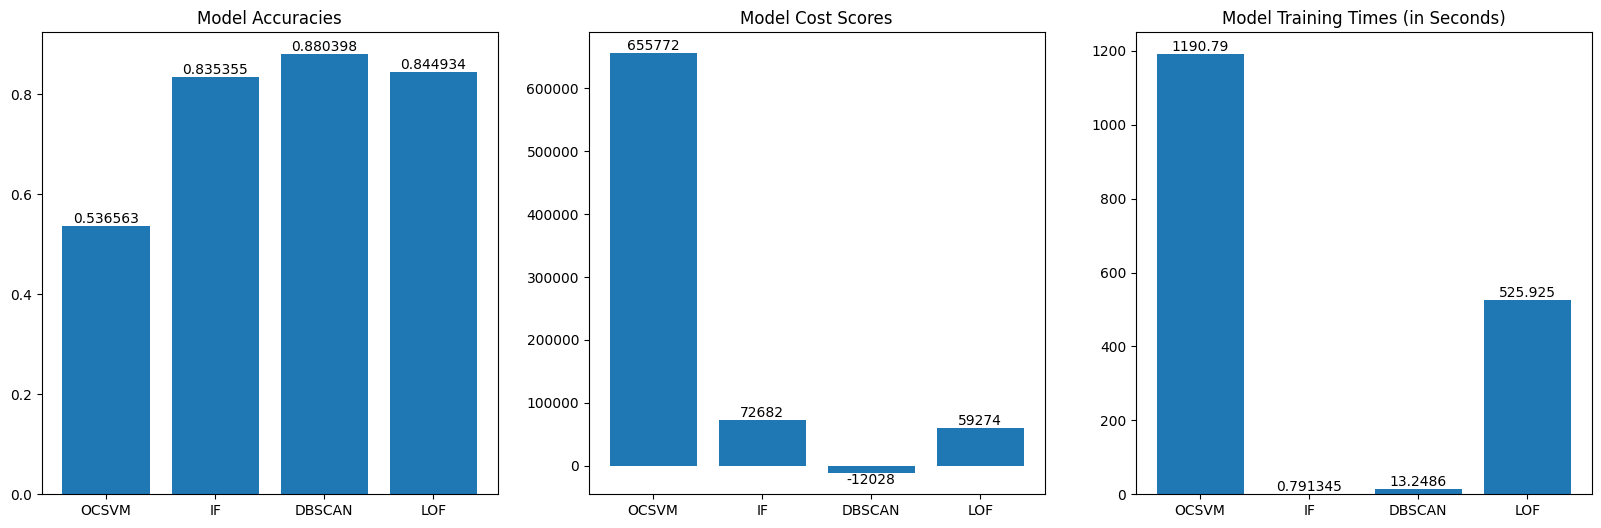

In [119]:
outlier_detec_accs = {
    "OCSVM": best_ocsvm_avg_acc,
    "IF": best_iso_avg_acc,
    "DBSCAN": best_dbscan_avg_acc,
    "LOF": best_lof_avg_acc   
}

outlier_detec_scores = {
    "OCSVM": best_ocsvm_avg_score,
    "IF": best_iso_avg_score,
    "DBSCAN": best_dbscan_avg_score,
    "LOF": best_lof_avg_score   
}

outlier_detec_times = {
    "OCSVM": ocsvm_train_time,
    "IF": iso_train_time,
    "DBSCAN": dbscan_train_time,
    "LOF": lof_train_time   
}

fig = plt.figure(figsize=(20,6))
ax = fig.add_subplot(1, 3, 1)
ax.set_title("Model Accuracies")
con = ax.bar(outlier_detec_accs.keys(), outlier_detec_accs.values())
ax.bar_label(con)

ax = fig.add_subplot(1, 3, 2)
ax.set_title("Model Cost Scores")
con = ax.bar(outlier_detec_scores.keys(), outlier_detec_scores.values())
ax.bar_label(con)

ax = fig.add_subplot(1, 3, 3)
ax.set_title("Model Training Times (in Seconds)")
con = ax.bar(outlier_detec_times.keys(), outlier_detec_times.values())
ax.bar_label(con)

plt.show()

From the graphs above, we can see that One-Class SVM did abysmally in terms of accuracy, cost score, and training time. All other models had at least one redeeming aspect to them. DBSCAN performed the best in terms of accuracy and cost score, while the Isolation Forest's training time was unparalled. While not incredibly impressive in any particular aspect, the LOF model was also not terrible. It ranked second in terms of accuracy and score, but its training time was undesirably high (though still better than One-Class SVM).

#### Comparing Outlier Detectors to Classifiers
Now we shall compare our outlier detectors to the classification models.


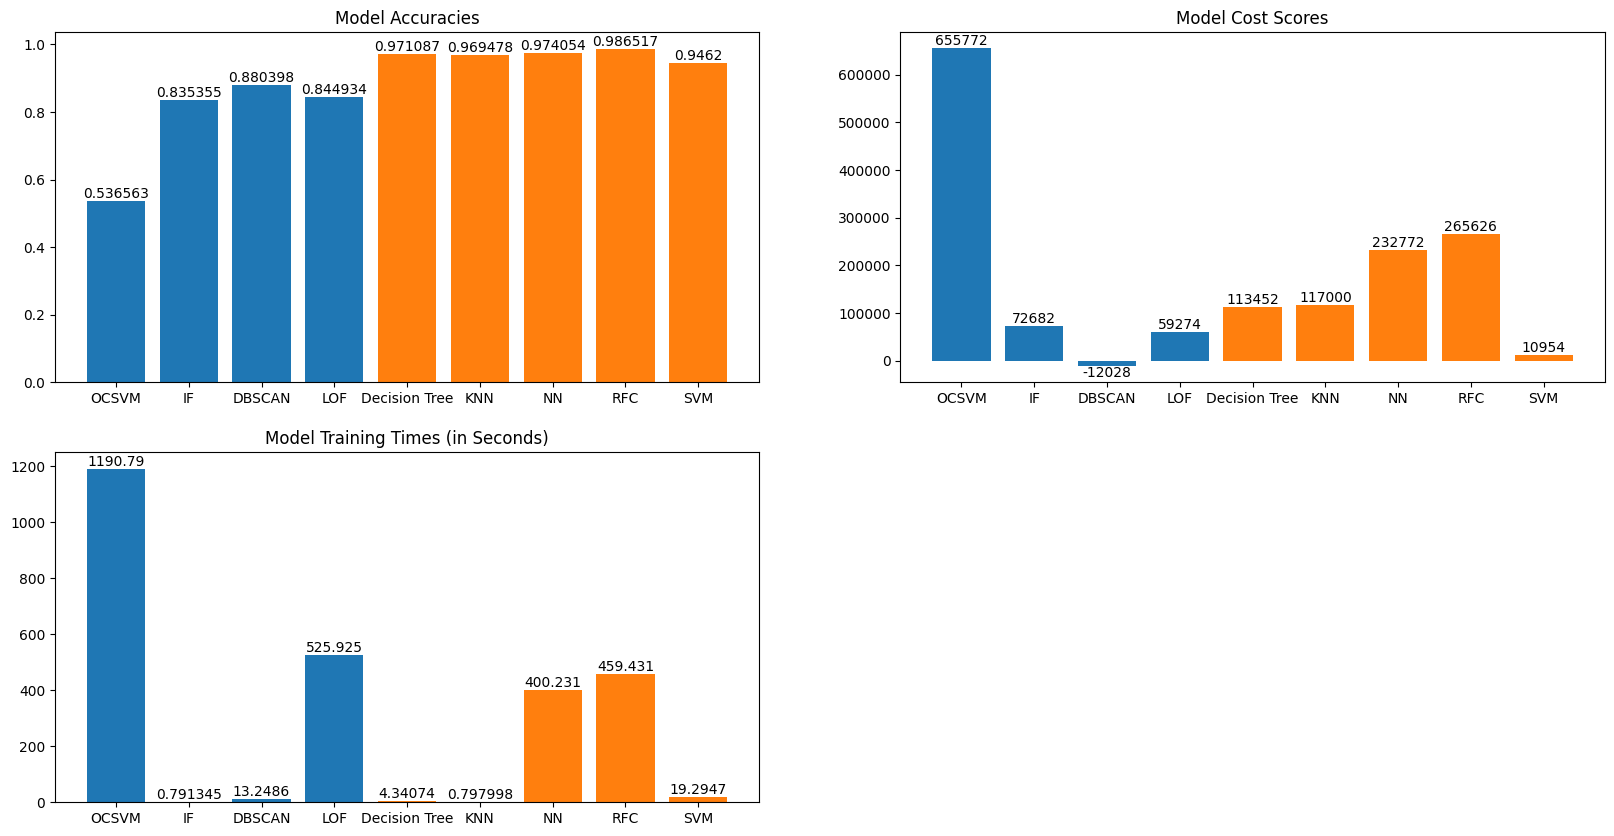

In [133]:
# using hard-coded numbers for the accuracies because those values were never stored as variables
class_accs = {
    "Decision Tree": 0.9710868586262615,
    "KNN": 0.9694776297316627,
    "NN": 0.9740536674525179,
    "RFC": 0.9865169134592461,
    "SVM": 0.9462
}
class_scores = {
    "Decision Tree": dec_tree_avg_score,
    "KNN": knn_avg_score,
    "NN": nn_avg_acc,
    "RFC": rfc.best_score_,
    "SVM": svm_model_1.best_score_
}
class_times = {
    "Decision Tree": dec_tree_train_time,
    "KNN": knn_train_time,
    "NN": train_time,
    "RFC": rfc_train_time,
    "SVM": svm_train_time_1
}

# fig, ax = plt.subplots(layout='constrained')
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(2, 2, 1)
ax.set_title("Model Accuracies")
con = ax.bar(outlier_detec_accs.keys(), outlier_detec_accs.values())
ax.bar_label(con)
con = ax.bar(class_accs.keys(), class_accs.values())
ax.bar_label(con)

ax = fig.add_subplot(2, 2, 2)
ax.set_title("Model Cost Scores")
con = ax.bar(outlier_detec_scores.keys(), outlier_detec_scores.values())
ax.bar_label(con)
con = ax.bar(class_scores.keys(), class_scores.values())
ax.bar_label(con)

ax = fig.add_subplot(2, 2, 3)
ax.set_title("Model Training Times (in Seconds)")
con =ax.bar(outlier_detec_times.keys(), outlier_detec_times.values())
ax.bar_label(con)
con =ax.bar(class_times.keys(), class_times.values())
ax.bar_label(con)

plt.show()

Above, we see our outlier detector models in blue and the classifiers in orange. A few observations we can make are that all classifiers outperform all outlier detectors in terms of accuracy. However, when we look at cost scores instead, we can see that our outlier detectors can actually perform better than classifiers. In fact, the best score is from the DBSCAN model, which actually has a _negative_ cost score!

Training times varied widely among and across groups. Interestingly, the Isolation Forest was much faster than both Decision Tree and the Random Forest, its classifier counterparts. DBSCAN also had an impressively low training time, though K-Nearest Neighbors, its closest classfier counterpart, had much better training time. 

## Conclusion and Final Remarks
If you were to only look at accuracy, you may dismiss the potential of outlier detector methods for this application since they were consistently outperformed by classifier models. However, if you take into account that we care a lot about decreasing our FP rate (and also a decent amount about decreasing our FN rate), we can see that outlier detectors can actually outperform classifiers. This experiment shows that outlier detectors have merit as malware detection methods. In particular, DBSCAN had the best cost score out of any model (classifier or outlier detector) and a reasonable training time. The other model to spotlight is the Isoloation Forest, which had the best training time out of any model and a reasonable cost score.

#### Limitations and Considerations
* **Must re-fit to predict on new data**- outlier detection models fit and predict all in one go, and only on the initial data points provided. To have it label new points, the model must be "re-fit" around the original dataset plus those new points. This has two implications for when using these types of models as malware detectors:
    1. **The cost of data storage** - outlier detectors will need to store _all_ the data points they need, which will become an ever-growing dataset as it is able to sample more files. Is it reasonable to expect users to store that much data on their machines? What can be done to reduce the storage cost? One potential solution is to try PCA dimentionality reduction so that the number of features stored can be scaled down.
    2. **"Training" time is critical**- in this context, the time it takes to train the model is the same as the time it takes to give a prediction on a single datapoint. Thus, training time is one of the crucial factors in which models are viable options for commercial usage as antivirus software (imagine having to wait 10 minutes _every_ single time you download a file from the internet for your antivirus software to check if it's safe).

#### Extentions
As mentioned above, timing is a crucial aspect of the practicality of a malware detection model. Timing could even be ingrained into the cost function we contrive for evaluating our models, giving out harsher penalties for taking longer. This would not change the models' behavior, but it would provide a more objective way to evaluate the tradeoffs between correctness and efficiency. 

Another potential extention of this project is to test how these models (both classifiers and outlier detectors) fare on novel malware by testing them on more recent data. This particular dataset was collected in 2018, so there are plenty of more recent malware datasets to test them on. Then we can see if outlier detectors really are more robust temporally than classification models.